In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train2/weights/best.pt")

In [2]:
video_path = "../videos/umpire_view.mp4"

cap = cv2.VideoCapture(video_path)

In [3]:
trajectory = []

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, conf=0.1)[0]

    if results.boxes is not None and len(results.boxes) > 0:

        box = results.boxes.xyxy.cpu().numpy()[0]

        x1, y1, x2, y2 = box

        cx = int((x1+x2)/2)
        cy = int((y1+y2)/2)

        trajectory.append((cx,cy))

cap.release()


0: 384x640 2 balls, 76.3ms
Speed: 6.3ms preprocess, 76.3ms inference, 7.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 33.3ms
Speed: 0.9ms preprocess, 33.3ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 34.6ms
Speed: 1.1ms preprocess, 34.6ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 34.1ms
Speed: 0.9ms preprocess, 34.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 34.3ms
Speed: 1.0ms preprocess, 34.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 34.8ms
Speed: 1.0ms preprocess, 34.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 37.5ms
Speed: 0.9ms preprocess, 37.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 35.8ms
Speed: 1.1ms preprocess, 35.8ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


In [4]:
print(len(trajectory))

264


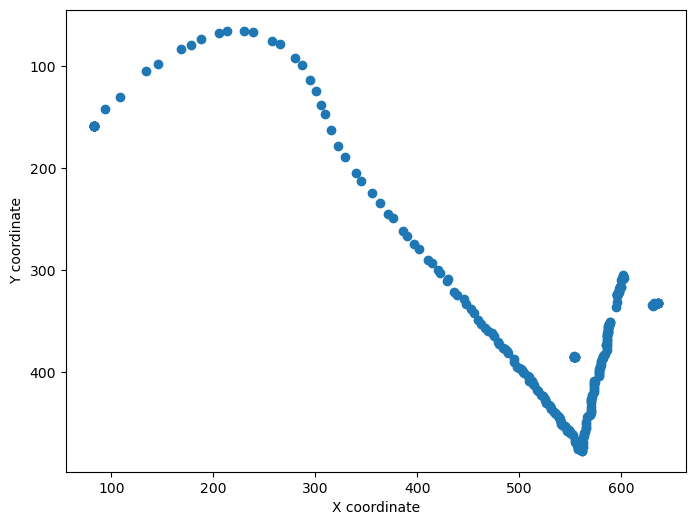

In [5]:
x = [p[0] for p in trajectory]
y = [p[1] for p in trajectory]

plt.figure(figsize=(8,6))
plt.scatter(x, y)

plt.gca().invert_yaxis()

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.show()

In [26]:
y = [p[1] for p in trajectory]

bounce_index = np.argmax(y)

print(bounce_index)
print(trajectory[bounce_index])

132
(562, 477)


In [27]:
pre_bounce = trajectory[20:bounce_index+1]
post_bounce = trajectory[bounce_index:bounce_index+40]

In [28]:
x_pre = [p[0] for p in pre_bounce]
y_pre = [p[1] for p in pre_bounce]

x_post = [p[0] for p in post_bounce]
y_post = [p[1] for p in post_bounce]

In [29]:
pre_coeff = np.polyfit(x_pre, y_pre, 2)
post_coeff = np.polyfit(x_post, y_post, 2)

In [30]:
x_pre_smooth = np.linspace(min(x_pre), max(x_pre), 200)
y_pre_smooth = np.polyval(pre_coeff, x_pre_smooth)

x_post_smooth = np.linspace(min(x_post), max(x_post), 100)
y_post_smooth = np.polyval(post_coeff, x_post_smooth)

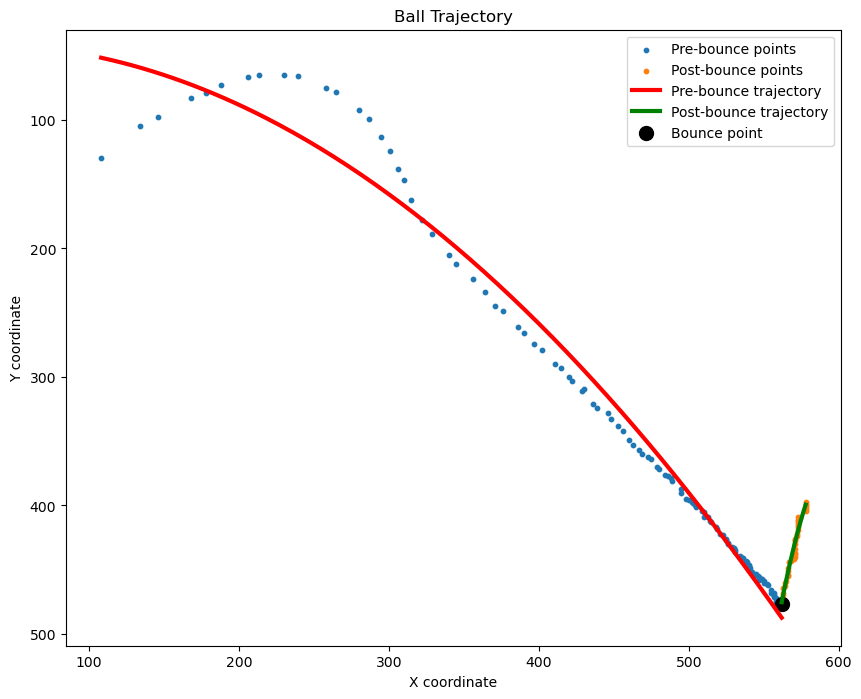

In [31]:
plt.figure(figsize=(10,8))

# Original points
plt.scatter(x_pre, y_pre, s=10, label="Pre-bounce points")
plt.scatter(x_post, y_post, s=10, label="Post-bounce points")

# Fitted curves
plt.plot(x_pre_smooth, y_pre_smooth,
         color='red',
         linewidth=3,
         label='Pre-bounce trajectory')

plt.plot(x_post_smooth, y_post_smooth,
         color='green',
         linewidth=3,
         label='Post-bounce trajectory')

# Bounce point
plt.scatter(
    trajectory[bounce_index][0],
    trajectory[bounce_index][1],
    color='black',
    s=100,
    label='Bounce point'
)

plt.gca().invert_yaxis()

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.legend()

plt.title("Ball Trajectory")

plt.show()